In [2]:
%load_ext autoreload
%autoreload 2

#import argparse
from   astropy import table
from   astropy.io import ascii, fits
from   astropy.coordinates import SkyCoord
from   astropy import units as u
from astropy.cosmology import Planck18

import copy
import corner
#import dynesty
import logging
#from   misc import bcolors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from   prospect.sources.constants import cosmo
from   prospect.fitting import fit_model, lnprobfn
from sedpy.observate import load_filters
import prospect.io.write_results as writer
import prospect.io.read_results as reader
#from   prospect.likelihood import lnlike_spec, lnlike_phot, write_log, chi_spec, chi_phot
#from   prospect.models import priors
#from   prospect.models.templates import TemplateLibrary
#import sfdmap
import sys
import time
import pandas as pd
import extinction
import vals

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
obj_name='AT2024wpp'
redshifts=vals.redshifts

# Spectrum file
spec_file={'AT2023hkw': 'data/AT2023hkw/AT2023hkw_Keck.txt', 'AT2023fhn': 'data/AT2023fhn/AT2023fhn_LRIS.txt',
           'AT2022abfc': 'data/AT2022abfc/AT2022abfc_GMOS_stack.txt', 'AT2023vth': 'data/AT2023vth/AT2023vth_GMOS2.txt',
          'AT2024aehp': 'data/AT2024aehp/AT2024aehp_binospec.txt'}

galaxy_mags={'AT2022abfc':[19.057, 18.124, 17.698,  17.464,
                            21.550,
                            17.356, 17.568, 15.875],
               'AT2023fhn': [19.452, 18.912, 18.606,  18.566,
                            20.60, 20.40, 19.34, 18.93, 18.84, 18.68,
                            20.913,
                            18.796, 18.755],
              'AT2023hkw': [20.706, 19.669, 18.996,
                            21.898,
                            18.833, 19.097],
               'AT2023vth': [19.54400062561035-0.11439372640168785, 18.888399124145508-0.11439372640168785, 18.484600067138672-0.11439372640168785, 18.293399810791016-0.11439372640168785,
                            21.601,
                            17.110+2.699,16.831+3.339],
             'AT2024qfm':[20.530, 19.706, 19.135,
                            19.156, 19.218],
            'AT2024aehp':[20.881, 20.454, 20.240,  20.232,
                            22.158, 21.902,
                            20.761, 20.468],
             'AT2024wpp':[22.115, 21.846, 21.859,
                          21.073, 21.5,
                          20.213, 20.294, 20.161,
                          19.879, 19.677, 19.74, 
                          19.481, 19.697, 19.479,
                          19.360,
                            20.335, 20.264],
}
galaxy_mag_err={'AT2022abfc':[0.002,  0.001, 0.001, 0.002,
                            0.310,
                            0.007, 0.015, 0.073],
               'AT2023fhn': [0.006,  0.006, 0.009, 0.009,
                            0.07, 0.03, 0.01, 0.01, 0.01, 0.02,
                            0.200,
                          0.024,0.051],
                'AT2023hkw': [0.014, 0.012, 0.010,
                            0.086,
                            0.022, 0.051],
               'AT2023vth': [0.019, 0.012, 0.008, 0.014,
                            0.274,
                            0.192, 0.380],
               'AT2024qfm':[0.007,  0.006, 0.007,
                            0.028, 0.067],
                'AT2024aehp':[0.009,  0.009, 0.013, 0.020,
                            0.181, 0.115,
                            0.117, 0.206],
                'AT2024wpp':[0.217, 0.210,  0.179,
                             0.453, 0.13,
                             0.07, 0.09, 0.05,
                             0.1, 0.05, 0.17,
                             0.11, 0.12, 0.05,
                             0.05,
                            0.1, 0.20],
}

b_v={'AT2022abfc': 0.0298, 'AT2023hkw': 0.0111, 'AT2023fhn': 0.0254, 'AT2023vth': 0.1801,'AT2024qfm':0.0421, 'AT2024wpp':0.0245, 'AT2024aehp':0.0245}
logz={'AT2023vth': -0.6, 'AT2024wpp':-0.4, 'AT2023fhn': -0.2702932382299956,
'AT2024aehp': -0.604597852295, 'AT2024qfm': -0.20465248279999798, 'AT2022abfc': 0.05491899643000091, 'AT2023hkw': 0.03484174200000151}

bands={'AT2022abfc':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                   'galex_NUV',
                    'wise_w1', 'wise_w2', 'wise_w3'],
       'AT2023fhn':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                    'wfc3_uvis_f225w', 'wfc3_uvis_f336w', 'wfc3_uvis_f555w','wfc3_uvis_f763m', 'wfc3_uvis_f814w', 'wfc3_uvis_f845m',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
      'AT2023hkw':['sdss_g0', 'sdss_r0','sdss_z0',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
        'AT2023vth':['panstarrs_g', 'panstarrs_r', 'panstarrs_i', 'panstarrs_z',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
       'AT2024qfm':['sdss_g0', 'sdss_r0', 'sdss_z0',
                    'wise_w1', 'wise_w2'],
      'AT2024aehp':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                    'galex_FUV', 'galex_NUV', 
                    'wise_w1', 'wise_w2'],
    'AT2024wpp':['uvot_w2', 'uvot_m2', 'uvot_w1',
                  'bessell_u', 'sdss_u0',
                  'sdss_g0', 'sdss_g0', 'sdss_g0',
                  'bessell_r', 'sdss_r0',  'sdss_r0',
                  'bessell_i', 'sdss_i0',  'sdss_i0',
                  'sdss_z0',
                    'wise_w1', 'wise_w2']}






In [4]:
# Set initial values

In [5]:
run_params = {}

In [6]:
# Object properties

In [7]:
run_params['zred']                    = redshifts[obj_name]
run_params['ldist']                   = Planck18.luminosity_distance(run_params['zred']).value
run_params['objname']                 = obj_name

In [8]:
# SED parameters

In [9]:
run_params['err_floor']               = 0.05

In [10]:
# Sampler params

In [11]:
run_params["nwalkers"]                = 128
run_params["niter"]                   = 512
run_params["nburn"]                   = [16, 32, 64]

run_params["nested_method"]           = "acceptance-walk"
run_params["nlive_init"]              = 400
run_params["nlive_batch"]             = 400
run_params["nested_dlogz_init"]       = 0.5
run_params["nested_posterior_thresh"] = 0.5
run_params["nested_rwalks"]           = 48
run_params['nested_weight_kwargs']    = {'pfrac': 1.0}
run_params['nested_maxcall']          = 3500000
run_params['nested_maxcall_init']     = 2500000
run_params['nested_maxbatch']         = None
run_params['nested_first_update']     = {'min_ncall': 20000, 'min_eff': 7.5}

In [12]:
EMCEE   = False
DYNESTY = True
OPTIMIZE= False

run_params["optimize"]          = OPTIMIZE
run_params["emcee"]             = EMCEE
run_params["dynesty"]           = DYNESTY
results_type                    = 'emcee' if EMCEE else 'dynesty' if DYNESTY else 'None'
hfile                           = "{name}_prospector_{sampler}.h5".format(name=run_params['objname'], sampler=results_type)

In [13]:
# Sigma Parameters for spectral fitting

Spectral resolution
* LRIS 400/3400 and 400/8500 have a FWHM of 6.5-7.1 AA and 6.9 AA, respectively (FWHM).
* The average FWHM is 6.8 AA. sigma = FWHM / 2.355. -> Mean sigma is 2.89 AA
* Assuming GMOS b600/r400 grating, R ~ 1700, which at 5000 AA gives a FWHM of ~ 3 AA
* Assuming Keck/Deimos 600 ZD grating, FWHM ~ 3.5 AA

In [14]:
sigma = {'AT2023fhn': 6.8/2.355, 'AT2022abfc': 3/2.355, 'AT2023vth': 3/2.355, 'AT2023hkw': 3.5/2.355}

In [15]:
## Photometry

In [16]:
# Apply extinction to photometry
mag=np.array(galaxy_mags[obj_name])

if obj_name=='AT2023fhn':
    header=166
else:
    header=0
    


# Milky Way Extinction for photometry
a_v = b_v[obj_name]*3.1

filters = load_filters([f"{b}" for b in bands[obj_name]])
phot_wave   = [f.wave_effective for f in filters]

mag-=extinction.fm07(np.array(phot_wave), a_v)
print(mag)



[21.89226996 21.60395522 21.6808979  20.95476033 21.38111301 20.11952871
 20.20052871 20.06752871 19.8186307  19.61212654 19.67512654 19.43938969
 19.65004896 19.43204896 19.32595247 20.33206391 20.26228671]


In [18]:
# Convert to maggies and create obs dictionary

phot_masks={'AT2022abfc': np.array([True]*8), 'AT2023hkw': np.array([True]*6),
        'AT2023fhn': np.array([True]*13), 'AT2023vth':  np.array([True]*7), 'AT2024qfm':  np.array([True]*5), 'AT2024aehp':  np.array([True]*8),
        'AT2024wpp':  np.array([True]*17)}



maggies = np.power(10, -0.4*mag)
magerr = np.array([0.05 for b in bands[obj_name]])
magerr = np.hypot(magerr, 0.05)

obs = dict(wavelength=None, spectrum=None, unc=None, redshift=redshifts[obj_name],
           maggies=maggies, maggies_unc=magerr * maggies / 1.086, filters=filters)



obs["phot_mask"] = phot_masks[obj_name]
obs["phot_wave"]=phot_wave


obs

{'wavelength': None,
 'spectrum': None,
 'unc': None,
 'redshift': 0.0868,
 'maggies': array([1.75021748e-09, 2.28253746e-09, 2.12637980e-09, 4.15045652e-09,
        2.80255921e-09, 8.95753507e-09, 8.31358836e-09, 9.39698464e-09,
        1.18181016e-08, 1.42938554e-08, 1.34880567e-08, 1.67588466e-08,
        1.38032202e-08, 1.68725381e-08, 1.86045433e-08, 7.36502857e-09,
        7.85389907e-09]),
 'maggies_unc': array([1.13958623e-10, 1.48618574e-10, 1.38450974e-10, 2.70240879e-10,
        1.82477774e-10, 5.83235155e-10, 5.41307063e-10, 6.11848210e-10,
        7.69489849e-10, 9.30688956e-10, 8.78222501e-10, 1.09118730e-09,
        8.98743151e-10, 1.09858988e-09, 1.21136268e-09, 4.79545271e-10,
        5.11376178e-10]),
 'filters': [<class 'sedpy.observate.Filter'>(uvot_w2),
  <class 'sedpy.observate.Filter'>(uvot_m2),
  <class 'sedpy.observate.Filter'>(uvot_w1),
  <class 'sedpy.observate.Filter'>(bessell_u),
  <class 'sedpy.observate.Filter'>(sdss_u0),
  <class 'sedpy.observate.Filter'

In [373]:
#Fitting to Spectra

#spec = pd.read_csv(spec_file[obj_name], sep=' +', engine='python', names=['wavelen', 'flux', 'flux_unc'], header=0)
#spec=spec.loc[pd.notna(spec['flux'])]

#spec.loc[:,'flux_jy_cal']=(np.array(spec['flux'])*u.erg/u.s/u.cm**2/u.AA).to(u.Jy, equivalencies=u.spectral_density(np.array(spec['wavelen'])*u.AA)).value
#spec.loc[:, 'flux_jy_unc']=1e23*spec.loc[:, 'flux_unc']*np.power(spec.loc[:, 'wavelen'], 2)/(3*10**18)

#bounds={'AT2022abfc': (4000, 8000), 'AT2023fhn': (3000, 6650), 'AT2023hkw': (3400, 8000), 'AT2023vth': (5000, 8000),
#       'AT2024aehp': (3100, 7500)}

#input_data=spec

#wave_rest = input_data.loc[:, 'wavelen'] / (1+redshifts[obj_name])


#mask = ((input_data['flux_jy_unc'] > 0) &
#                (input_data['flux_jy_cal'] != 0)
#                )

#phot_filter=input_data.loc[mask]

#mask_telluric = (np.abs(wave_rest[mask] - 6873) > 15) & (np.abs(wave_rest[mask] - 7610) > 20)

obs = dict(wavelength=np.array(phot_filter['wavelen']), spectrum=np.array(phot_filter['flux_jy_cal'])/3631, unc=np.array(phot_filter['flux_jy_unc']/3631), redshift=redshifts[obj_name],
           maggies=maggies, maggies_unc=magerr * maggies / 1.086, filters=filters, mask=np.array(mask_telluric),
          phot_mask=phot_masks[obj_name], phot_wave=phot_wave)

obs

NameError: name 'input_data' is not defined

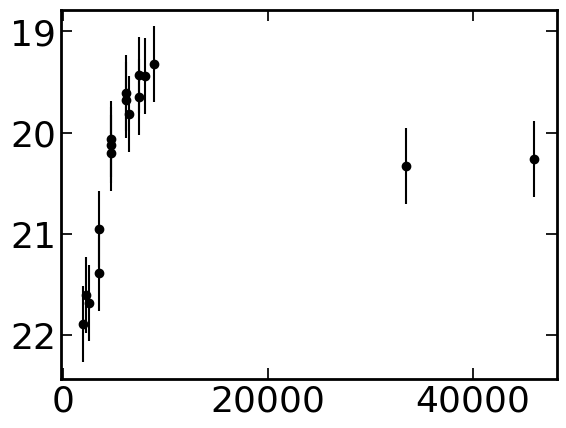

In [21]:
# Show the observaations
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
                    
ax.plot(obs["phot_wave"], np.log10(obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(obs["phot_wave"],  np.log10(obs["maggies"])/-0.4, np.log(10)*np.divide(obs["maggies_unc"], obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
#ax.plot(obs["wavelength"], np.log10(obs["spectrum"])/-0.4)
ax.invert_yaxis()
#plt.savefig('figures/{}_input.png'.format(obj_name))

In [22]:
from prospect.models.templates import TemplateLibrary
from prospect.models import PolySpecModel, priors

model_params = TemplateLibrary["parametric_sfh"]
#model_params.update(TemplateLibrary["nebular"])

# --- Mass ---
model_params["mass"]["init"] = 1e10
model_params["mass"]["disp_floor"] = 1e6
model_params["mass"]["prior"] = priors.LogUniform(mini=1e5, maxi=1e13)
    
# Redshift and luminosity distance
model_params["lumdist"] = {"N": 1, "isfree": False, "init": (Planck18.luminosity_distance(z=redshifts[obj_name])).to(u.Mpc).value, "units":"Mpc"}

# --- Use C3K everywhere ---
#model_params["use_wr_spectra"] = dict(N=1, isfree=False, init=0)
#model_params["logt_wmb_hot"]   = dict(N=1, isfree=False, init=np.log10(5e4))

# --- SFH ---

model_params["sfh"]['init'] = 4
model_params["sfh"]['isfree'] = False

model_params["tage"]["prior"] = priors.LogUniform(mini=0.001, maxi=13.8) # Gyr
model_params["tage"]["init"] = 1
model_params["tage"]["disp_floor"] = 0.1

model_params["tau"]["prior"] = priors.LogUniform(mini=1e-1, maxi=1e2) # Gyr
model_params["tau"]["init"] = 1
model_params["tau"]["disp_floor"] = 0.1

# If you want to let metallicity be free
model_params["logzsol"]["isfree"]=True
model_params["logzsol"]["prior"] = priors.TopHat(mini=-3.5, maxi=0.5)

# If you want to specify a metallicity, which is recommended if you only have photometry
#model_params["logzsol"]["isfree"]=False
#model_params["logzsol"]["init"] = -0.2

model_params["zred"]["init"] = redshifts[obj_name]
model_params["zred"]['isfree'] = False

# For Chabrier, want imf_type = 1, dust_type=2

model_params["imf_type"]["init"] = 1
model_params["dust_type"]["init"] = 2
model_params["dust2"]["prior"] = priors.TopHat(mini=0.0, maxi=8.0)
model_params["dust2"]["init"] = 0.05  # dust absorption


# Parameters for fitting to spectroscopy

#model_params['nebemlineinspec']["init"] = False
#model_params['nebemlineinspec']["isfree"] = False

#model_params['gas_logu']['isfree'] = True

#model_params['gas_logz']['isfree'] = True
#_ = model_params["gas_logz"].pop("depends_on")


#model_params.update(TemplateLibrary['spectral_smoothing'])
#model_params["sigma_smooth"]["prior"] = priors.TopHat(mini=50.0, maxi=300.0)

#model_params.update(TemplateLibrary['nebular_marginalization'])

#model_params['eline_prior_width']['init'] = 10.0
#model_params['use_eline_prior']['init'] = True

            # only marginalize over a few (strong) emission lines

to_fit = ['Ba-gamma 4341',
            'Ba-beta 4861', '[O III] 4959', '[O III] 5007',
            '[N II] 6548', 'Ba-alpha 6563', '[N II] 6584', 
            '[S II] 6716', '[S II] 6731'
            ]
#model_params['elines_to_fit']['init'] = to_fit

#model_params.update(TemplateLibrary['optimize_speccal'])
#model_params['spec_norm']['isfree'] = False
#model_params["polyorder"]["init"] = 12

#model_params['nsigma_outlier_spec'] = dict(N=1, isfree=False, init=50.)
#model_params['f_outlier_spec'] = dict(N=1, isfree=True, init=0.01,
#                                              prior=priors.TopHat(mini=1e-5, maxi=0.1))
model_params['nsigma_outlier_phot'] = dict(N=1, isfree=False, init=50.)
model_params['f_outlier_phot'] = dict(N=1, isfree=False, init=0.0,
                                              prior=priors.TopHat(mini=0, maxi=0.5))
#model_params['spec_jitter'] = dict(N=1, isfree=True, init=1.0,
#                                           prior=priors.TopHat(mini=1.0, maxi=3.0))




model = PolySpecModel(model_params)
model



:::::::
<class 'prospect.models.sedmodel.PolySpecModel'>

Free Parameters: (name: prior) 
-----------
  mass: <class 'prospect.models.priors.LogUniform'>(mini=100000.0,maxi=10000000000000.0)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=8.0)
  tage: <class 'prospect.models.priors.LogUniform'>(mini=0.001,maxi=13.8)
  tau: <class 'prospect.models.priors.LogUniform'>(mini=0.1,maxi=100.0)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.0868] 
  logzsol: [-0.4] 
  sfh: [4] 
  imf_type: [1] 
  dust_type: [2] 
  lumdist: [409.38461436] 
  nsigma_outlier_phot: [50.] 
  f_outlier_phot: [0.] 

In [431]:
from prospect.sources import CSPSpecBasis, FastStepBasis
sps = CSPSpecBasis(zcontinuous=1)
# Below sps is used for non-parametric fitting
#sps=FastStepBasis()

In [432]:
noise_model = build_noise(**run_params)
noise_model

(None, None)

In [433]:
output = fit_model(obs, model, sps, lnprobfn=lnprobfn, noise=noise_model, **run_params)

iter: 2111 | batch: 0 | nc: 1 | ncall: 9637 | eff(%): 21.905 | logz: 289.399 +/-  0.430 | dlogz:  0.005 >  0.500             


done dynesty (initial) in 68.99213171005249s


iter: 15483 | batch: 24 | nc: 1 | ncall: 40941 | eff(%): 33.946 | loglstar: 300.169 < 308.714 < 307.977 | logz: 289.475 +/-  0.127 | stop:  1.019     

done dynesty (dynamic) in 135.6421890258789s


In [434]:
result, duration = output["sampling"]

In [435]:
obj_name

'AT2024wpp'

In [436]:
hfile = "./data/{}/{}.h5".format(obj_name, obj_name[2:])
writer.write_hdf5(hfile, {}, model, obs,
                 output["sampling"][0], None,
                                 sps=sps,
                 tsample=output["sampling"][1],
                 toptimize=0.0)

/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:60: RuntimeWarning: Could not store paramfile text
  warnings.warn("Could not store paramfile text", RuntimeWarning)
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:301: RuntimeWarning: Could not JSON serialize model_params, pickled instead
  warnings.warn("Could not JSON serialize {}, pickled instead".format(k),
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:49: RuntimeWarning: Could not obtain prospector version info
  warnings.warn("Could not obtain prospector version info", RuntimeWarning)


In [437]:
# Diagnostic plots

In [31]:
hfile = "./data/{}/{}_fixedZ_-0.4_noneb.h5".format(obj_name, obj_name[2:])
out, out_obs, out_model = reader.results_from(hfile)

In [24]:
imax = np.argmax(out['lnprobability'])
theta_max = out["chain"][imax, :]
print(theta_max)

[8.33311893e+08 2.29719343e-04 1.44562680e+00 2.53357391e-01]


['mass', 'dust2', 'tage', 'tau']

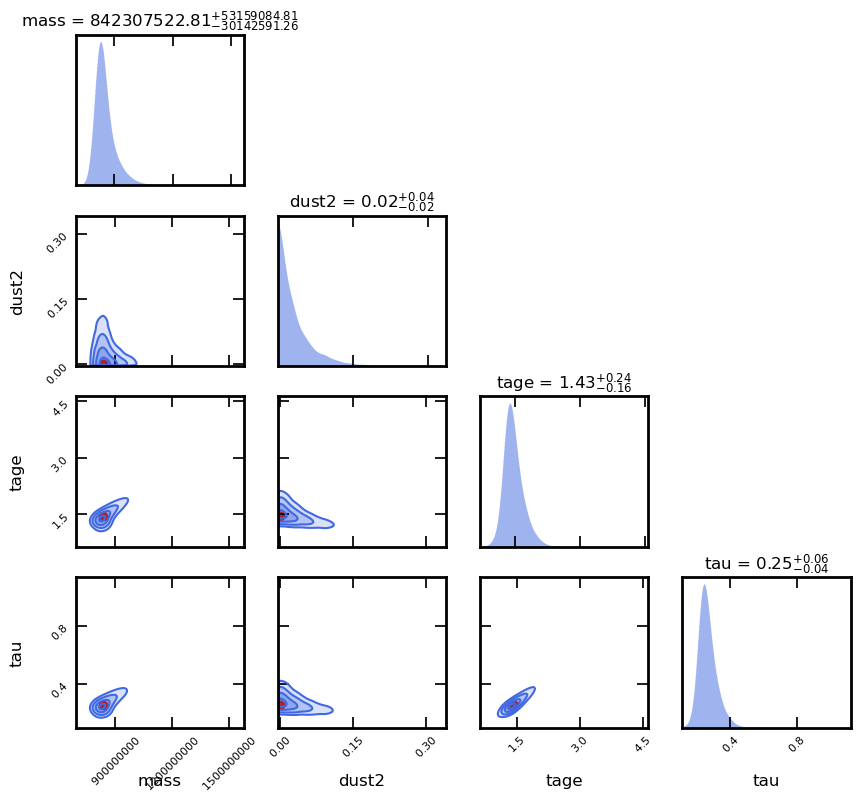

In [25]:
import matplotlib.pyplot as pl
from prospect.plotting import corner
nsamples, ndim = out["chain"].shape
cfig, axes = pl.subplots(ndim, ndim, figsize=(10,9))
axes = corner.allcorner(out["chain"].T, out["theta_labels"], axes, weights=out["weights"], color="royalblue", show_titles=True)

from prospect.plotting.utils import best_sample
pbest = best_sample(out)
corner.scatter(pbest[:, None], axes, color="firebrick", marker="o")
out["theta_labels"]

{'parameter': array([8.33311893e+08, 2.29719343e-04, 1.44562680e+00, 2.53357391e-01]), 'photometry': array([1.88659056e-09, 1.98355492e-09, 2.11759716e-09, 3.29074517e-09,
       3.23708664e-09, 9.29561828e-09, 9.29561828e-09, 9.29561828e-09,
       1.32247980e-08, 1.28704651e-08, 1.28704651e-08, 1.53302015e-08,
       1.44586122e-08, 1.44586122e-08, 1.65488727e-08, 9.25332970e-09,
       5.35147238e-09]), 'restframe_wavelengths': array([9.100e+01, 9.400e+01, 9.600e+01, ..., 9.817e+07, 9.908e+07,
       1.000e+08]), 'spectrum': array([3.47930499e-15, 2.89745005e-15, 3.78597554e-15, ...,
       4.51396948e-14, 4.39439823e-14, 4.15723812e-14]), 'mfrac': 0.6656502011211921}


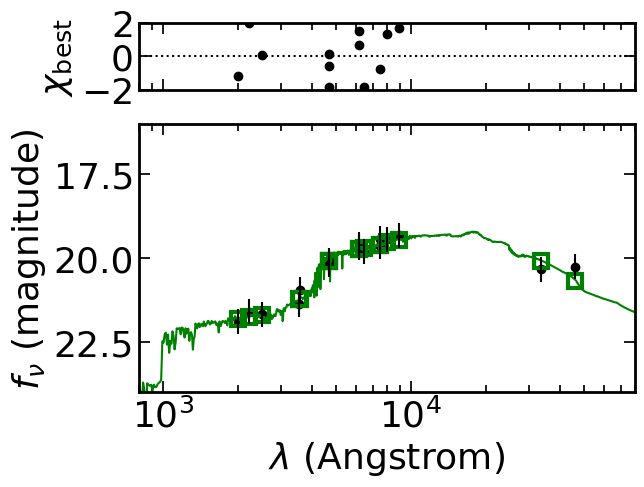

In [26]:
import matplotlib.pyplot as pl
sfig, saxes = pl.subplots(2, 1, gridspec_kw=dict(height_ratios=[1, 4]), sharex=True)
ax = saxes[1]
ax.ticklabel_format(axis='y', style='plain')
pwave = np.array([f.wave_effective for f in out_obs["filters"]])
# plot the data
ax.plot(pwave, np.log10(out_obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(pwave,  np.log10(out_obs["maggies"])/-0.4, np.log(10)*np.divide(out_obs["maggies_unc"], out_obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
ax.set_ylabel(r"$f_\nu$ (magnitude)")
ax.set_xlabel(r"$\lambda$ (Angstrom)")
ax.set_xlim(800, 8e4)
#ax.set_xlim(6500*(1+redshifts[obj_name]), 6800*(1+redshifts[obj_name]))
ax.set_ylim(24, 16)
ax.set_xscale('log')

# get the best-fit SED
bsed = out["bestfit"]
print(bsed)
ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed["spectrum"])/-0.4, color="green", label="MAP sample")
ax.plot(pwave, np.log10(bsed["photometry"])/-0.4, linestyle="", marker="s", markersize=10, mec="green", mew=3, mfc="none")


ax = saxes[0]
chi = (out_obs["maggies"] - bsed["photometry"]) / out_obs["maggies_unc"]
ax.plot(pwave, chi, linestyle="", marker="o", color="k")
ax.axhline(0, color="k", linestyle=":")
ax.set_ylim(-2, 2)
ax.set_ylabel(r"$\chi_{\rm best}$")
plt.savefig('AT2024wpp_allphot.png', dpi=300)

# Save the fitted spectrum to a data file
#pd.DataFrame(data={'rest_wave': bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), 'flux': bsed["spectrum"]}).to_csv('data/AT2024wpp/2024wpp_z-0.4_noneb.csv')

    


{'parameter': array([ 3.37087565e+10,  4.50892283e-01,  1.68802924e+00,  3.71254659e-01,
        4.84268068e-01, -3.90867258e+00]), 'photometry': array([5.47702446e-09, 1.41684906e-08, 2.44346312e-08, 1.91283603e-09,
       2.84283011e-08, 2.40207845e-08]), 'restframe_wavelengths': array([9.100e+01, 9.400e+01, 9.600e+01, ..., 9.817e+07, 9.908e+07,
       1.000e+08]), 'spectrum': array([ 2.10965768e-11, -2.42014733e-14, -4.01696849e-16, ...,
        7.04500543e-10,  7.04182506e-10,  6.82180015e-10]), 'mfrac': 0.6752320952998688}


/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2105/1894516056.py:15: RuntimeWarning: invalid value encountered in log10
  ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed["spectrum"])/-0.4, color=vals.colors[obj_name], label="Prospector Fit")
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2105/1894516056.py:17: RuntimeWarning: invalid value encountered in log10
  ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed['spectrum'] )/-0.4, color="black", alpha=0.23, label='Observed Spectrum')


Text(0.5, 1.0, 'AT2023hkw Host Galaxy Fit')

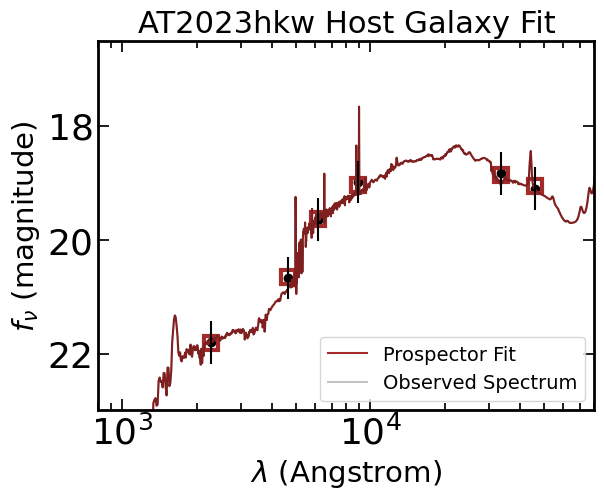

In [752]:
# More clean plot

fig=plt.figure()
ax=fig.add_subplot(1,1,1)

pwave = np.array([f.wave_effective for f in out_obs["filters"]])
# plot the data
ax.plot(pwave/(1+redshifts[obj_name]), np.log10(out_obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(pwave/(1+redshifts[obj_name]),  np.log10(out_obs["maggies"])/-0.4, np.log(10)*np.divide(out_obs["maggies_unc"], out_obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
ax.set_ylabel(r"$f_\nu$ (magnitude)", fontsize=21)
ax.set_xlabel(r"$\lambda$ (Angstrom)", fontsize=21)

# get the best-fit SED
bsed = out["bestfit"]
indices = np.nonzero((bsed["spectrum"]>0)&(bsed["restframe_wavelengths"]<70000)&(bsed["restframe_wavelengths"]>1300))[0]
print(bsed)
ax.plot(bsed["restframe_wavelengths"], np.log10(bsed["spectrum"])/-0.4, color=vals.colors[obj_name], label="Prospector Fit")
ax.plot(pwave/(1+redshifts[obj_name]), np.log10(bsed["photometry"])/-0.4, linestyle="", marker="s", markersize=10, mec=vals.colors[obj_name], mew=3, mfc="none")
ax.plot(bsed["restframe_wavelengths"], np.log10(bsed['spectrum'] )/-0.4, color="black", alpha=0.23, label='Observed Spectrum')

ax.set_xlim(800, 8e4)
ax.set_xscale('log')
ax.set_ylim(np.max(np.log10(bsed["spectrum"][indices])/-0.4)+0.8, np.min(np.log10(bsed["spectrum"][indices])/-0.4)-1)
ax.legend(prop={'size': 14})

ax.set_title('{} Host Galaxy Fit'.format(obj_name), fontsize=22)
#plt.savefig('figures/{}_specfit.png'.format(obj_name))

In [445]:
from prospect.plotting.sfh import parametric_sfr

# This is for getting the total mass and fitted star-formation rate if you used a paramteric sfh.
# The star-formation rate caclulation might take a while
def weighted_percentile(data, weights, perc):
    """
    perc : percentile in [0-1]!
    """
    ix = np.argsort(data)
    data = data[ix] # sort data
    weights = weights[ix] # sort weights
    cdf = (np.cumsum(weights) - 0.5 * weights) / np.sum(weights) # 'like' a CDF function
    return list(map(str, np.interp(perc, cdf, data)))

params=out["chain"].T

# The mass in the list of parameters is the total stellar mass formed, you maybe only want the mass of 'alive' stellar mass
mass_alive=[]
for param in out["chain"]:
    mfrac=model.predict(param, obs=out_obs, sps=sps)[2]
    mass_alive.append(param[0]*mfrac)

# Depends on if you have set metallicity to be free or fixed

fixed_Z=True
if fixed_Z:
    # Assumes this set of free parameters ['mass', 'dust2', 'tage', 'tau', 'gas_logz', 'gas_logu']
    sfrs=parametric_sfr(times=0, tavg=0.001, tage=params[2], mass=params[0], logzsol=logz[obj_name],dust2=params[1],tau=params[3])
    print("Log Total Mass: ");print(','.join(weighted_percentile(np.log10(params[0]), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Z/Z_sun: ");print(logz[obj_name])
    print("Age: ");print(','.join(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84])))
    print("Dust Optical Depth: ");print(','.join(weighted_percentile(params[1], out["weights"], [0.16, 0.5, 0.84])))
    print("SFR: ");print(','.join(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84])))
    print(len(params[0]))
else:
    # Assumes this set of free parameters ['mass', 'logzsol', 'dust2', 'tage', 'tau', 'gas_logz', 'gas_logu']
    sfrs=parametric_sfr(times=0, tavg=0.001, tage=params[3], mass=params[0], logzsol=params[1],dust2=params[2],tau=params[4])
    print("Log Total Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Z/Z_sun: ");print(','.join(weighted_percentile(params[1], out["weights"], [0.16, 0.5, 0.84])))
    print("Age: ");print(','.join(weighted_percentile(params[3], out["weights"], [0.16, 0.5, 0.84])))
    print("Dust Optical Depth: ");print(','.join(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84])))
    print("SFR: ");print(','.join(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84])))
    print(len(params[0]))

#print("Log Total Mass: ");print(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84]))
#print("Log Mass: ");print(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84]))
#print("Log Z/Z_sun: ");print(weighted_percentile(params[0], out["weights"], [0.16, 0.5, 0.84]))
#print("Age: ");print(weighted_percentile(params[3], out["weights"], [0.16, 0.5, 0.84]))
#print("SFR: ");print(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84]))

Log Total Mass: 
8.909643129885762,8.925468201890169,8.952044110252647
Log Mass: 
8.735848376910427,8.750259306609818,8.771730992849628
Log Z/Z_sun: 
-0.4
Age: 
1.2705646679723044,1.4271248937818264,1.6670279017821792
Dust Optical Depth: 
0.005582106383703201,0.022649081809045315,0.06310043800042238
SFR: 
0.06300917517447953,0.06985733173624216,0.07756963449696677
13083


In [74]:
TemplateLibrary.show_contents()

'type_defaults':
  Explicitly sets dust amd IMF types.
'ssp':
  Basic set of (free) parameters for a delta function SFH
'parametric_sfh':
  Basic set of (free) parameters for a delay-tau SFH.
'dust_emission':
  The set of (fixed) dust emission parameters.
'nebular':
  The set of nebular emission parameters, with gas_logz tied to stellar logzsol.
'nebular_marginalization':
  Marginalize over emission amplitudes line contained inthe observed spectrum
'fit_eline_redshift':
  Fit for the redshift of the emission lines separatelyfrom the stellar redshift
'agn_eline':
  Add AGN emission lines
'outlier_model':
  The set of outlier (mixture) models for spectroscopy and photometry
'agn':
  The set of (fixed) AGN dusty torus emission parameters.
'igm':
  The set of (fixed) IGM absorption parameters.
'spectral_smoothing':
  Set of parameters for spectal smoothing.
'optimize_speccal':
  Set of parameters (most of which are fixed) for optimizing a polynomial calibration vector.
'fit_speccal':
  Set